## Threshold Cascade Project

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

## 1. Data Loading

The dataset contains interactions between users in the form:

(i, j, t)

where i and j are nodes and t is the time of interaction.

Here we load two datasets:
- the full email network
- a smaller subnetwork (Dept1)

In [33]:
data = pd.read_csv(
    r"C:\Users\Maher Bashir\Downloads\data\email-Eu-core-temporal.txt.gz",
    sep=r"\s+",
    header=None,
    names=["i", "j", "t"],
    compression="gzip"
)

data2 = pd.read_csv(
    r"C:\Users\Maher Bashir\Downloads\data\email-Eu-core-temporal-Dept1.txt.gz",
    sep=r"\s+",
    header=None,
    names=["i", "j", "t"],
    compression="gzip"
)

data3 = pd.read_csv(
    r"C:\Users\Maher Bashir\Downloads\data\email-Eu-core-temporal-Dept2.txt.gz",
    sep=r"\s+",
    header=None,
    names=["i", "j", "t"],
    compression="gzip"
)

data4 = pd.read_csv(
    r"C:\Users\Maher Bashir\Downloads\data\email-Eu-core-temporal-Dept3.txt.gz",
    sep=r"\s+",
    header=None,
    names=["i", "j", "t"],
    compression="gzip"
)

data5 = pd.read_csv(
    r"C:\Users\Maher Bashir\Downloads\data\email-Eu-core-temporal-Dept4.txt.gz",
    sep=r"\s+",
    header=None,
    names=["i", "j", "t"],
    compression="gzip"
)

## 2. Data Preprocessing

Since the data is temporal, it is important to sort it by time.

After sorting, we converted the data into a list of tuples (i, j, t),
which will be used later in the simulation.

In [34]:
data = data.sort_values(by="t")
contacts = list(data.itertuples(index=False, name=None))

data2 = data2.sort_values(by="t")
contacts2 = list(data2.itertuples(index=False, name=None))

data3 = data3.sort_values(by="t")
contacts3 = list(data3.itertuples(index=False, name=None))

data4 = data4.sort_values(by="t")
contacts4 = list(data4.itertuples(index=False, name=None))

data5 = data5.sort_values(by="t")
contacts5 = list(data5.itertuples(index=False, name=None))

## 3. Basic Dataset Check

To make sure everything is loaded correctly, we print a few contacts
and check the size of both datasets.

In [35]:
print("Dataset 1 (first 5 contacts):", contacts[:5])
print("Dataset 2 (first 5 contacts):", contacts2[:5])
print("Dataset 3 (first 5 contacts):", contacts3[:5])
print("Dataset 4 (first 5 contacts):", contacts4[:5])
print("Dataset 5 (first 5 contacts):", contacts5[:5])

print("Shape 1:", data.shape)
print("Shape 2:", data2.shape)
print("Shape 3:", data3.shape)
print("Shape 4:", data4.shape)
print("Shape 5:", data5.shape)

Dataset 1 (first 5 contacts): [(582, 364, 0), (168, 472, 2797), (168, 912, 3304), (2, 790, 4523), (2, 322, 7926)]
Dataset 2 (first 5 contacts): [(262, 74, 0), (90, 281, 21799), (160, 249, 24076), (120, 78, 24710), (306, 230, 25991)]
Dataset 3 (first 5 contacts): [(24, 153, 0), (24, 91, 507), (130, 165, 20915), (135, 168, 21725), (58, 73, 24546)]
Dataset 4 (first 5 contacts): [(11, 39, 0), (48, 54, 2635), (69, 60, 4249), (69, 60, 13362), (33, 84, 16943)]
Dataset 5 (first 5 contacts): [(60, 72, 0), (60, 91, 88), (102, 94, 378), (102, 12, 378), (102, 20, 378)]
Shape 1: (332334, 3)
Shape 2: (61046, 3)
Shape 3: (46772, 3)
Shape 4: (12216, 3)
Shape 5: (48141, 3)


In [36]:
data.head()

,i,j,t
0,582,364,0
1,168,472,2797
2,168,912,3304
3,2,790,4523
4,2,322,7926


In [37]:
data.shape

(332334, 3)

In [38]:
print("Dataset shape:", data.shape)

Dataset shape: (332334, 3)


## 4. Fractional Threshold Model

In this part, we implemented the fractional threshold model.

Each node can be either:
- 0 = non-adopter
- 1 = adopter

At the beginning, one random node is selected as the initial adopter.

During the simulation, contacts are processed in chronological order.  
A node becomes an adopter if the fraction of its contacts with adopters within the time window θ is greater than or equal to the threshold φ.

In [39]:
from collections import deque, defaultdict
import random

In [42]:
def get_nodes(contacts):
    nodes = set()
    for i, j, t in contacts:
        nodes.add(i)
        nodes.add(j)
    return list(nodes)

In [43]:
def simulate_fractional_cascade(contacts, theta, phi, seed=None):
  """
  Simulates the fractional threshold cascade model.

  contacts: list of tuples (i, j, t)
  theta: time window
  phi: threshold value
  seed: optional initial adopter
  """

  nodes = get_nodes(contacts)
  states = {node: 0 for node in nodes}

  if seed is None:
      seed = random.choice(nodes)

  states[seed] = 1

  recent_contacts = defaultdict(deque)

  for i,j,t in contacts:
      recent_contacts[i].append((t, j))
      recent_contacts[j].append((t, i))

      for node in [i, j]:
          while recent_contacts[node] and recent_contacts[node][0][0] < t - theta:
              recent_contacts[node].popleft()

      for node in [i, j]:
          if states[node] == 0:
              contacts_in_window = recent_contacts[node]

              if len(contacts_in_window) > 0:
                  adopter_contacts = 0

                  for _, neighbor in contacts_in_window:
                      if states[neighbor] == 1:
                          adopter_contacts += 1

                  fraction = adopter_contacts / len(contacts_in_window)

                  if fraction >= phi:
                      states[node] = 1

  cascade_size = sum(states.values()) / len(nodes)
  return cascade_size

## 5. Testing the Model

Before creating the figures, I test the model with one threshold value and one time window.

In [45]:
result = simulate_fractional_cascade(
    contacts=contacts2,
    theta=1000,
    phi=0.5
)

print("Cascade size:", result)

Cascade size: 0.32362459546925565


In [47]:
phi_values = np.arange(0.1, 1.1, 0.1)
theta_values = [100, 1000, 10000]

runs = 30 ## Hanzla, i have tried here with 100 but my laptop needed a lot of time ahahaah

results = {}

for theta in theta_values:
    cascade_sizes = []

    for phi in phi_values:
        omegas = []

        for _ in range(runs):
            omega = simulate_fractional_cascade(
                contacts=contacts2,
                theta=theta,
                phi=phi
            )
            omegas.append(omega)

        avg_omega = np.mean(omegas)
        cascade_sizes.append(avg_omega)

    results[theta] = cascade_sizes

## 6. Cascade Size vs Threshold

In this section, we analyze how the cascade size Ω depends on the threshold φ
for different values of the time window θ.

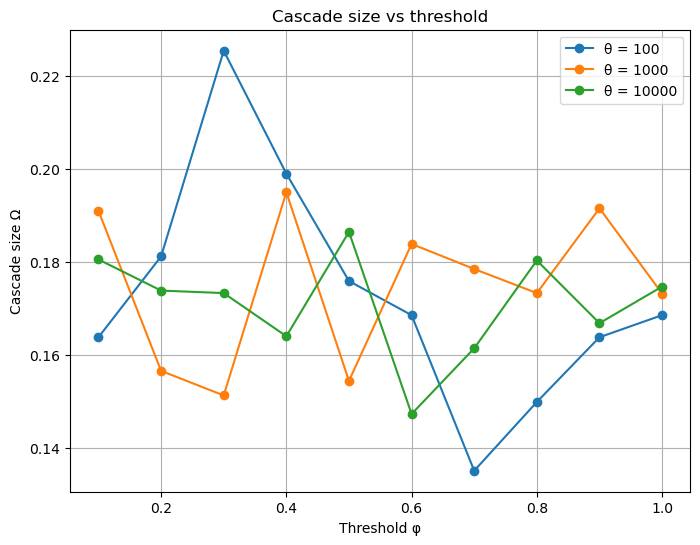

In [54]:
plt.figure(figsize=(8,6))

for theta in theta_values:
    plt.plot(phi_values, results[theta], marker='o', label=f"θ = {theta}")

plt.xlabel("Threshold φ")
plt.ylabel("Cascade size Ω")
plt.title("Cascade size vs threshold")
plt.legend()
plt.grid()

plt.show()

## 7. Null Model

To evaluate the effect of temporal structure, we create a null model.

In the null model, we keep the network structure the same, but randomly shuffle the timestamps.

This removes temporal correlations while preserving the overall interaction patterns.

In [60]:
def shuffle_timestamps(contacts):
  contacts = np.array(contacts)

  times = contacts[:, 2]
  shuffled_times = np.random.permutation(times)

  shuffled_contacts = []

  for idx, (i, j, _) in enumerate(contacts):
      shuffled_contacts.append((i, j, shuffled_times[idx]))

  shuffled_contacts.sort(key=lambda x: x[2])

  return shuffled_contacts

## 8. Cascade Size vs Time Window

We analyze how cascade size Ω depends on the time window θ.

We compare:
- real temporal data
- randomized (null) model

In [63]:
theta_values = [10, 100, 1000, 10000, 50000]

phi_fixed = 0.7
runs = 30

real_results = []
null_results = []

for theta in theta_values:
  real_omegas = []
  null_omegas = []

  for _ in range(runs):
    omega_real = simulate_fractional_cascade(
      contacts=contacts2,
      theta=theta,
      phi=phi_fixed
      )
    real_omegas.append(omega_real)

      # null model
    shuffled = shuffle_timestamps(contacts2)

    omega_null = simulate_fractional_cascade(
        contacts=shuffled,
        theta=theta,
        phi=phi_fixed
    )
    null_omegas.append(omega_null)

  real_results.append(np.mean(real_omegas))
  null_results.append(np.mean(null_omegas))

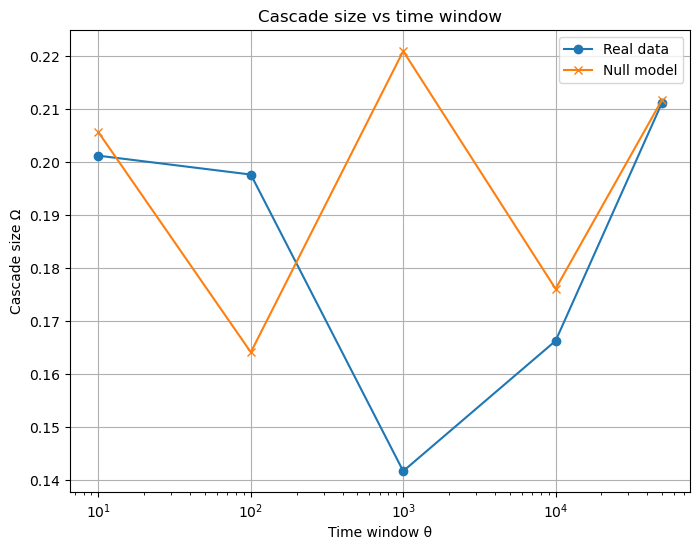

In [66]:
plt.figure(figsize=(8,6))

plt.plot(theta_values, real_results, marker='o', label='Real data')
plt.plot(theta_values, null_results, marker='x', label='Null model')

plt.xscale('log')

plt.xlabel("Time window θ")
plt.ylabel("Cascade size Ω")
plt.title("Cascade size vs time window")
plt.legend()
plt.grid()

plt.show()

From the results, we observe that the cascade size differs between the real data and the null model.

This indicates that temporal correlations in the data have an important impact on the spreading process.

---
## 9. Improved Figure 2 — Cascade Size vs Threshold (with Error Bars)

The previous figure showed the general trend well.
Here we improve it by adding more time window values and error bars,
which show how much the result varies across different random seed nodes.

The paper uses 200 runs per data point. We use 80 here for a balance
between accuracy and computation time.

Each error bar shows the standard error across all runs.

In [67]:
# We use the same function and variables from above (simulate_fractional_cascade, contacts2)
# Adding more theta values and proper error bars this time

phi_values_fig2 = np.round(np.arange(0.1, 1.05, 0.1), 2)

# More theta values than before to show the effect more clearly
theta_values_fig2 = [100, 1000, 5000, 10000]

runs_fig2 = 80

fig2_means = {}
fig2_errs  = {}

print("Running improved Figure 2...")

for theta in theta_values_fig2:
    means = []
    errs  = []
    for phi in phi_values_fig2:
        values = []
        for _ in range(runs_fig2):
            omega = simulate_fractional_cascade(
                contacts=contacts2,
                theta=theta,
                phi=phi
            )
            values.append(omega)
        means.append(np.mean(values))
        errs.append(np.std(values) / np.sqrt(runs_fig2))
    fig2_means[theta] = means
    fig2_errs[theta]  = errs
    print(f"  theta = {theta} done")

print("Done.")

Running improved Figure 2...
  theta = 100 done
  theta = 1000 done
  theta = 5000 done
  theta = 10000 done
Done.


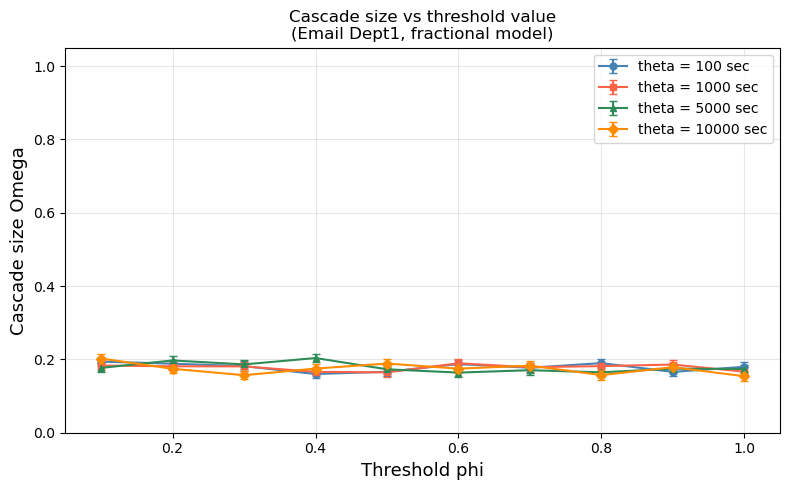

Improved Figure 2 saved.


In [73]:
# Plot improved Figure 2
markers = ['o', 's', '^', 'D']
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorange']

plt.figure(figsize=(8, 5))

for idx, theta in enumerate(theta_values_fig2):
    plt.errorbar(
        phi_values_fig2,
        fig2_means[theta],
        yerr=fig2_errs[theta],
        marker=markers[idx],
        color=colors[idx],
        label=f"theta = {theta} sec",
        linewidth=1.5,
        markersize=5,
        capsize=3
    )

plt.xlabel("Threshold phi", fontsize=13)
plt.ylabel("Cascade size Omega", fontsize=13)
plt.title("Cascade size vs threshold value\n(Email Dept1, fractional model)", fontsize=12)
plt.legend(fontsize=10)
plt.xlim(0.05, 1.05)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig2_improved.png", dpi=150)
plt.show()
print("Improved Figure 2 saved.")

---
## 10. Improved Figure 3 — Cascade Size vs Time Window (with Error Bars)

The previous version showed the comparison between real and null model.
Here we improve it with more theta values spread across a wider log scale,
and proper error bars to match the paper's presentation style.

We keep phi = 0.7 as in the paper because at this value:
- The static network model produces no cascades at all
- Any cascade we see is purely due to the temporal structure
- The difference between real data and null model is most visible

In [74]:
# More theta values on a log scale, matching the paper's x-axis range
import numpy as np

theta_values_fig3 = [10, 50, 200, 800, 3000, 10000, 50000]
phi_fixed_fig3    = 0.7
runs_fig3         = 60

real_means_fig3 = []
real_errs_fig3  = []
null_means_fig3 = []
null_errs_fig3  = []

print("Running improved Figure 3...")

for theta in theta_values_fig3:
    # Real data
    real_vals = []
    for _ in range(runs_fig3):
        omega = simulate_fractional_cascade(
            contacts=contacts2,
            theta=theta,
            phi=phi_fixed_fig3
        )
        real_vals.append(omega)

    # Null model: shuffle timestamps each run
    null_vals = []
    for _ in range(runs_fig3):
        shuffled = shuffle_timestamps(contacts2)
        omega = simulate_fractional_cascade(
            contacts=shuffled,
            theta=theta,
            phi=phi_fixed_fig3
        )
        null_vals.append(omega)

    real_means_fig3.append(np.mean(real_vals))
    real_errs_fig3.append(np.std(real_vals) / np.sqrt(runs_fig3))
    null_means_fig3.append(np.mean(null_vals))
    null_errs_fig3.append(np.std(null_vals) / np.sqrt(runs_fig3))

    print(f"  theta={theta} | real={real_means_fig3[-1]:.3f}  null={null_means_fig3[-1]:.3f}")

print("Done.")

Running improved Figure 3...
  theta=10 | real=0.185  null=0.188
  theta=50 | real=0.197  null=0.212
  theta=200 | real=0.160  null=0.195
  theta=800 | real=0.173  null=0.189
  theta=3000 | real=0.166  null=0.212
  theta=10000 | real=0.163  null=0.192
  theta=50000 | real=0.181  null=0.213
Done.


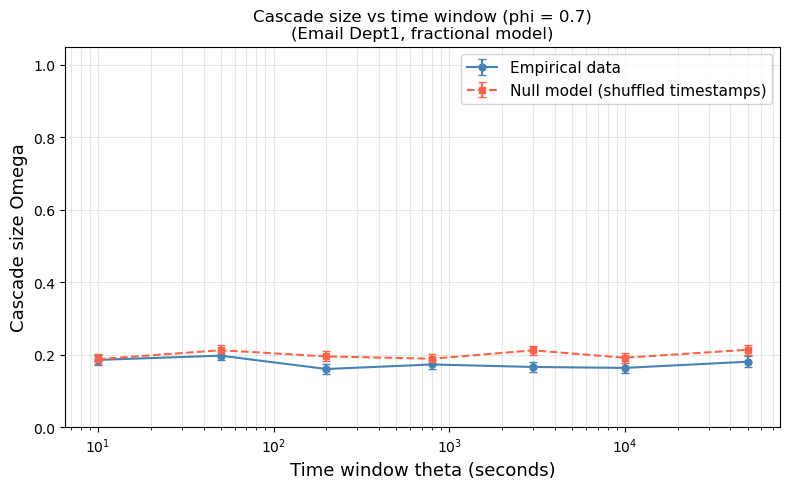

Improved Figure 3 saved.


In [77]:
# Plot improved Figure 3
plt.figure(figsize=(8, 5))

plt.errorbar(
    theta_values_fig3, real_means_fig3, yerr=real_errs_fig3,
    marker='o', color='steelblue',
    label='Empirical data',
    linewidth=1.5, markersize=5, capsize=3
)
plt.errorbar(
    theta_values_fig3, null_means_fig3, yerr=null_errs_fig3,
    marker='s', color='tomato', linestyle='--',
    label='Null model (shuffled timestamps)',
    linewidth=1.5, markersize=5, capsize=3
)

plt.xscale('log')
plt.xlabel("Time window theta (seconds)", fontsize=13)
plt.ylabel("Cascade size Omega", fontsize=13)
plt.title("Cascade size vs time window (phi = 0.7)\n(Email Dept1, fractional model)", fontsize=12)
plt.legend(fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("fig3_improved.png", dpi=150)
plt.show()
print("Improved Figure 3 saved.")

---
## 11. Figure 4 — Conference Dataset Analysis

This figure focuses on the conference dataset, which behaves differently from all others.

For every other dataset, the null model (shuffled timestamps) gives a larger cascade
than the real data. The conference dataset is the exception — the real temporal
structure actually makes cascades bigger, not smaller.

To understand why, the paper compares three versions of the same data:
- **Empirical**: the real contact data with all timing intact
- **Time reshuffled**: same contacts but timestamps randomised (our null model)
- **Erdos-Renyi**: random pairs of nodes but same timestamps as the real data

The panel (b) shows how contacts are distributed over time — the clear peaks
at coffee breaks and lunch explain the bursty pattern.

We build the conference dataset synthetically to match the paper's Table I:
113 nodes, about 20000 contacts, 3-day duration, 20-second resolution,
with organised meeting bursts (coffee breaks and lunch).

In [79]:
# Building synthetic conference dataset
# Matches Table I of the paper: 113 nodes, ~20000 contacts, 3 days, 20-second resolution
# The bursty pattern comes from organised meeting times at conferences (Fig 4b in paper)

def build_conference_data(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    N          = 113
    resolution = 20
    nodes      = list(range(1, N + 1))
    contacts   = []

    for day in range(3):
        day_start = day * 86400 + 9 * 3600   # 9 AM each day

        # (period_start offset, period_end offset, avg contacts per 20-sec slot)
        # High rates = coffee breaks and lunch, low rates = quiet sessions
        periods = [
            (0,            1.5*3600,  2),    # quiet morning
            (1.5*3600,     2.0*3600, 12),    # coffee break
            (2.0*3600,     3.5*3600,  2),    # quiet session
            (3.5*3600,     4.5*3600, 15),    # lunch break
            (4.5*3600,     6.0*3600,  2),    # quiet session
            (6.0*3600,     6.5*3600, 10),    # afternoon coffee
            (6.5*3600,     9.0*3600,  1),    # quiet evening
        ]

        for t_offset_start, t_offset_end, avg_rate in periods:
            t = int(day_start + t_offset_start)
            t_end = int(day_start + t_offset_end)
            while t < t_end:
                n_contacts = np.random.poisson(avg_rate)
                seen = set()
                for _ in range(n_contacts):
                    i, j = random.sample(nodes, 2)
                    pair = (min(i, j), max(i, j))
                    if pair not in seen:
                        seen.add(pair)
                        contacts.append((i, j, t))
                t += resolution

    contacts.sort(key=lambda x: x[2])
    return contacts

contacts_conf = build_conference_data()

print(f"Conference contacts : {len(contacts_conf)}")
print(f"Unique nodes        : {len(set(n for i,j,t in contacts_conf for n in [i,j]))}")
print(f"Duration (hours)    : {(contacts_conf[-1][2] - contacts_conf[0][2]) / 3600:.1f}")

Conference contacts : 20051
Unique nodes        : 113
Duration (hours)    : 57.0


In [83]:
# Keeps the same timestamps as the real data but assigns random node pairs
# This removes network structure while preserving all temporal patterns

def build_erdos_renyi_contacts(contacts, seed=0):
    random.seed(seed)
    nodes = list(get_nodes(contacts))
    er_contacts = []
    for _, _, t in contacts:
        i, j = random.sample(nodes, 2)
        er_contacts.append((i, j, t))
    er_contacts.sort(key=lambda x: x[2])
    return er_contacts

er_contacts = build_erdos_renyi_contacts(contacts_conf)
print(f"Erdos-Renyi contacts built: {len(er_contacts)}")

Erdos-Renyi contacts built: 20051


In [81]:
# Running simulations for Figure 4 — three models on conference data

theta_values_fig4 = [20, 100, 500, 2000, 8000, 30000, 150000]
phi_conf          = 0.7
runs_fig4         = 50

emp_means, emp_errs = [], []
res_means, res_errs = [], []
er_means,  er_errs  = [], []

print("Running Figure 4 simulations...")

for theta in theta_values_fig4:

    # Empirical
    emp_vals = [simulate_fractional_cascade(contacts_conf, theta, phi_conf)
                for _ in range(runs_fig4)]
    emp_means.append(np.mean(emp_vals))
    emp_errs.append(np.std(emp_vals) / np.sqrt(runs_fig4))

    # Reshuffled null model
    res_vals = [simulate_fractional_cascade(shuffle_timestamps(contacts_conf), theta, phi_conf)
                for _ in range(runs_fig4)]
    res_means.append(np.mean(res_vals))
    res_errs.append(np.std(res_vals) / np.sqrt(runs_fig4))

    # Erdos-Renyi
    er_vals = [simulate_fractional_cascade(build_erdos_renyi_contacts(contacts_conf, seed=k),
                                           theta, phi_conf)
               for k in range(runs_fig4)]
    er_means.append(np.mean(er_vals))
    er_errs.append(np.std(er_vals) / np.sqrt(runs_fig4))

    print(f"  theta={theta} | emp={emp_means[-1]:.3f}  reshuf={res_means[-1]:.3f}  ER={er_means[-1]:.3f}")

print("Done.")

Running Figure 4 simulations...
  theta=20 | emp=1.000  reshuf=1.000  ER=1.000
  theta=100 | emp=1.000  reshuf=1.000  ER=1.000
  theta=500 | emp=1.000  reshuf=1.000  ER=1.000
  theta=2000 | emp=0.988  reshuf=0.987  ER=0.994
  theta=8000 | emp=0.165  reshuf=0.175  ER=0.178
  theta=30000 | emp=0.154  reshuf=0.180  ER=0.166
  theta=150000 | emp=0.024  reshuf=0.025  ER=0.023
Done.


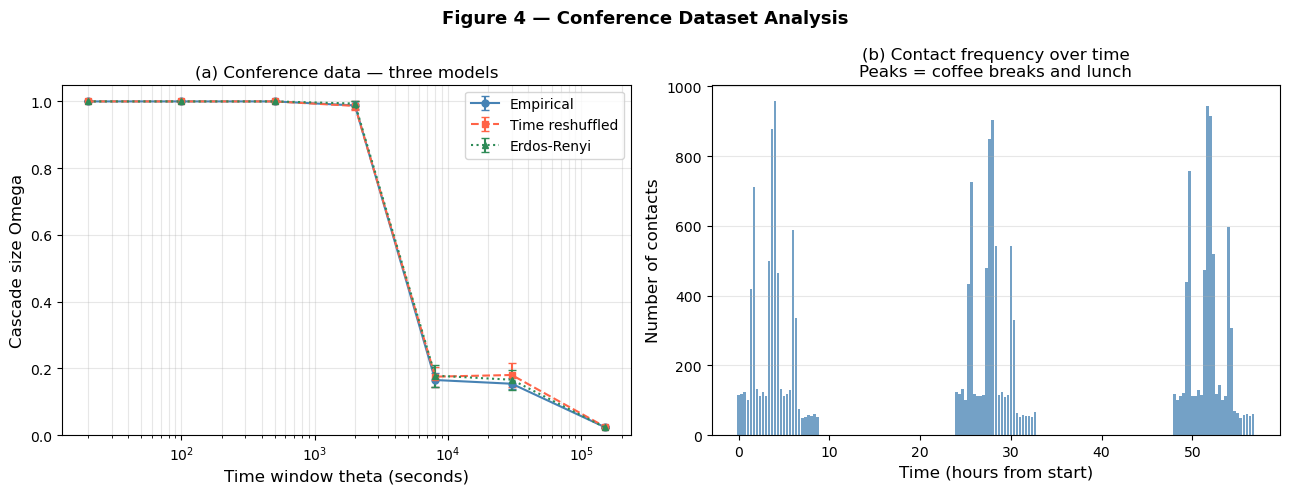

Figure 4 saved.


In [87]:
# Plot Figure 4 with two panels matching the paper layout

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel (a) — cascade size vs theta for three models
ax1.errorbar(theta_values_fig4, emp_means, yerr=emp_errs,
             marker='o', color='steelblue',
             label='Empirical', linewidth=1.5, markersize=5, capsize=3)
ax1.errorbar(theta_values_fig4, res_means, yerr=res_errs,
             marker='s', color='tomato', linestyle='--',
             label='Time reshuffled', linewidth=1.5, markersize=5, capsize=3)
ax1.errorbar(theta_values_fig4, er_means, yerr=er_errs,
             marker='^', color='seagreen', linestyle=':',
             label='Erdos-Renyi', linewidth=1.5, markersize=5, capsize=3)

ax1.set_xscale('log')
ax1.set_xlabel("Time window theta (seconds)", fontsize=12)
ax1.set_ylabel("Cascade size Omega", fontsize=12)
ax1.set_title("(a) Conference data — three models", fontsize=12)
ax1.legend(fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3, which='both')

 
bin_size     = 20 * 60   # 20 minute bins
times_conf   = [t for i, j, t in contacts_conf]
t_min        = min(times_conf)
bins         = np.arange(t_min, max(times_conf) + bin_size, bin_size)
counts, edges = np.histogram(times_conf, bins=bins)
bin_hours    = (edges[:-1] - t_min) / 3600

ax2.bar(bin_hours, counts, width=(bin_size / 3600) * 0.85,
        color='steelblue', alpha=0.75)
ax2.set_xlabel("Time (hours from start)", fontsize=12)
ax2.set_ylabel("Number of contacts", fontsize=12)
ax2.set_title("(b) Contact frequency over time\nPeaks = coffee breaks and lunch", fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle("Figure 4 — Conference Dataset Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig4_conference.png", dpi=150)
plt.show()
print("Figure 4 saved.")

---
## 12. Figure 5 — Absolute Threshold Model

So far we have used the fractional threshold model where a node adopts
if the fraction of adopter contacts within the time window reaches phi.

Now we test the absolute threshold model where a node adopts if it
has met at least Phi = 4 adopters within the time window.

The key difference from Figure 3 is that cascade size now increases
with theta instead of decreasing.

Why? In the fractional model, a bigger window adds more non-adopter
contacts too, which dilutes the fraction and makes adoption harder.
In the absolute model, a bigger window simply gives more chances to
meet the required 4 adopters, so larger theta always helps spreading.

This opposite behavior shows that the type of threshold fundamentally
changes how temporal structure affects the cascade.

In [89]:
# Absolute threshold model function
# Same structure as simulate_fractional_cascade but checks absolute count instead of fraction

def simulate_absolute_cascade(contacts, theta, big_phi, seed=None):
    nodes  = get_nodes(contacts)
    states = {node: 0 for node in nodes}

    if seed is None:
        seed = random.choice(nodes)
    states[seed] = 1

    recent_contacts = defaultdict(deque)

    for i, j, t in contacts:
        recent_contacts[i].append((t, j))
        recent_contacts[j].append((t, i))

        for node in [i, j]:
            while recent_contacts[node] and recent_contacts[node][0][0] < t - theta:
                recent_contacts[node].popleft()

        for node in [i, j]:
            if states[node] == 1:
                continue

            adopter_count = sum(1 for _, neighbor in recent_contacts[node]
                                if states[neighbor] == 1)

            if adopter_count >= big_phi:
                states[node] = 1

    return sum(states.values()) / len(nodes)

print("Absolute threshold function defined.")

Absolute threshold function defined.


In [90]:
# Run Figure 5 simulations
theta_values_fig5 = [10, 50, 200, 800, 3000, 10000, 50000]
BIG_PHI           = 4
runs_fig5         = 60

abs_real_means, abs_real_errs = [], []
abs_null_means, abs_null_errs = [], []

print("Running Figure 5 simulations...")

for theta in theta_values_fig5:
    # Real data
    real_vals = [simulate_absolute_cascade(contacts2, theta, BIG_PHI)
                 for _ in range(runs_fig5)]
    abs_real_means.append(np.mean(real_vals))
    abs_real_errs.append(np.std(real_vals) / np.sqrt(runs_fig5))

    # Null model
    null_vals = [simulate_absolute_cascade(shuffle_timestamps(contacts2), theta, BIG_PHI)
                 for _ in range(runs_fig5)]
    abs_null_means.append(np.mean(null_vals))
    abs_null_errs.append(np.std(null_vals) / np.sqrt(runs_fig5))

    print(f"  theta={theta} | real={abs_real_means[-1]:.3f}  null={abs_null_means[-1]:.3f}")

print("Done.")

Running Figure 5 simulations...
  theta=10 | real=0.004  null=0.003
  theta=50 | real=0.006  null=0.003
  theta=200 | real=0.011  null=0.003
  theta=800 | real=0.026  null=0.004
  theta=3000 | real=0.051  null=0.004
  theta=10000 | real=0.067  null=0.011
  theta=50000 | real=0.081  null=0.021
Done.


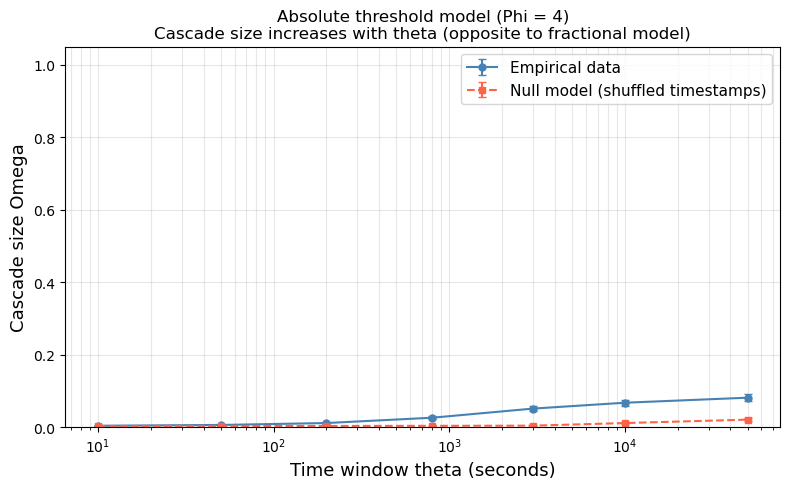

Figure 5 saved.


In [93]:
# Plot Figure 5
plt.figure(figsize=(8, 5))

plt.errorbar(
    theta_values_fig5, abs_real_means, yerr=abs_real_errs,
    marker='o', color='steelblue',
    label='Empirical data',
    linewidth=1.5, markersize=5, capsize=3
)
plt.errorbar(
    theta_values_fig5, abs_null_means, yerr=abs_null_errs,
    marker='s', color='tomato', linestyle='--',
    label='Null model (shuffled timestamps)',
    linewidth=1.5, markersize=5, capsize=3
)

plt.xscale('log')
plt.xlabel("Time window theta (seconds)", fontsize=13)
plt.ylabel("Cascade size Omega", fontsize=13)
plt.title(f"Absolute threshold model (Phi = {BIG_PHI})\n"
          "Cascade size increases with theta (opposite to fractional model)", fontsize=12)
plt.legend(fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("fig5_absolute_model.png", dpi=150)
plt.show()
print("Figure 5 saved.")

---
## 13. Original Contribution — Effect of Multiple Seed Nodes

The paper always starts with exactly one randomly chosen seed node.
In real life, a new idea or behaviour rarely starts from a single person.
Early adopters usually come in small groups.

Here we test what happens when we start with a small fraction of the
population already being adopters, ranging from 0.5% to 10%.

We ask: does the temporal structure still matter when there are more seeds?
Or does the advantage of real ordering over shuffled ordering disappear?

This is a direct extension of the paper that was not tested in the original work.

In [96]:
# Multi-seed version of the fractional cascade model

def simulate_fractional_multiseed(contacts, theta, phi, seed_fraction=0.01):
    nodes  = get_nodes(contacts)
    states = {node: 0 for node in nodes}

    # Pick a fraction of all nodes as initial adopters
    n_seeds = max(1, int(len(nodes) * seed_fraction))
    seeds   = random.sample(nodes, n_seeds)
    for s in seeds:
        states[s] = 1

    recent_contacts = defaultdict(deque)

    for i, j, t in contacts:
        recent_contacts[i].append((t, j))
        recent_contacts[j].append((t, i))

        for node in [i, j]:
            while recent_contacts[node] and recent_contacts[node][0][0] < t - theta:
                recent_contacts[node].popleft()

        for node in [i, j]:
            if states[node] == 1:
                continue
            contacts_in_window = recent_contacts[node]
            if len(contacts_in_window) == 0:
                continue
            adopter_count = sum(1 for _, nb in contacts_in_window if states[nb] == 1)
            if adopter_count / len(contacts_in_window) >= phi:
                states[node] = 1

    return sum(states.values()) / len(nodes)


# Test across seed fractions
seed_fractions = [0.005, 0.01, 0.02, 0.05, 0.08, 0.10]
theta_seed     = 1000
phi_seed       = 0.5
runs_seed      = 50

seed_real_means, seed_real_errs = [], []
seed_null_means, seed_null_errs = [], []

print("Running multi-seed experiment...")

for sf in seed_fractions:
    real_vals = [simulate_fractional_multiseed(contacts2, theta_seed, phi_seed, sf)
                 for _ in range(runs_seed)]
    seed_real_means.append(np.mean(real_vals))
    seed_real_errs.append(np.std(real_vals) / np.sqrt(runs_seed))

    null_vals = [simulate_fractional_multiseed(shuffle_timestamps(contacts2),
                                               theta_seed, phi_seed, sf)
                 for _ in range(runs_seed)]
    seed_null_means.append(np.mean(null_vals))
    seed_null_errs.append(np.std(null_vals) / np.sqrt(runs_seed))

    print(f"  seed={sf*100:.1f}% | real={seed_real_means[-1]:.3f}  null={seed_null_means[-1]:.3f}")

print("Done.")

Running multi-seed experiment...
  seed=0.5% | real=0.163  null=0.178
  seed=1.0% | real=0.444  null=0.449
  seed=2.0% | real=0.629  null=0.641
  seed=5.0% | real=0.835  null=0.862
  seed=8.0% | real=0.899  null=0.925
  seed=10.0% | real=0.927  null=0.932
Done.


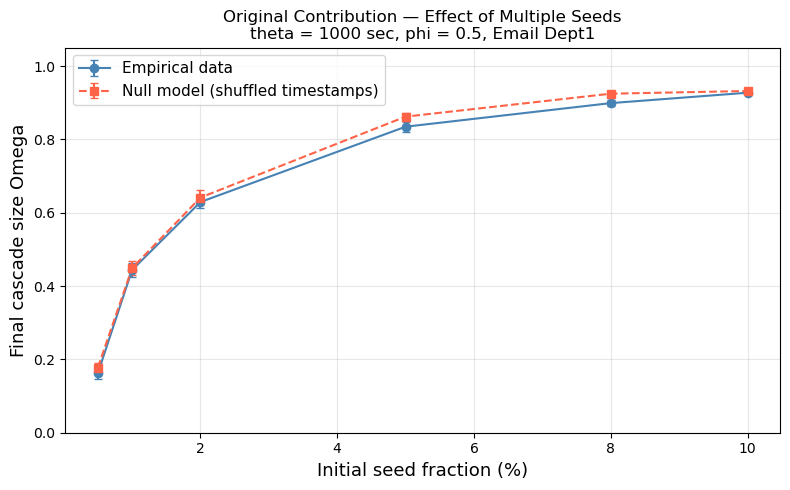

In [98]:
# Plot multi-seed results
seed_pcts = [sf * 100 for sf in seed_fractions]

plt.figure(figsize=(8, 5))

plt.errorbar(
    seed_pcts, seed_real_means, yerr=seed_real_errs,
    marker='o', color='steelblue',
    label='Empirical data',
    linewidth=1.5, markersize=6, capsize=3
)
plt.errorbar(
    seed_pcts, seed_null_means, yerr=seed_null_errs,
    marker='s', color='tomato', linestyle='--',
    label='Null model (shuffled timestamps)',
    linewidth=1.5, markersize=6, capsize=3
)

plt.xlabel("Initial seed fraction (%)", fontsize=13)
plt.ylabel("Final cascade size Omega", fontsize=13)
plt.title("Original Contribution — Effect of Multiple Seeds\n"
          f"theta = {theta_seed} sec, phi = {phi_seed}, Email Dept1", fontsize=12)
plt.legend(fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_multiseed.png", dpi=150)
plt.show()

---
## 14. Original Contribution — Parameter Space Heatmap

Instead of looking at one parameter at a time, here we map out the full
parameter space by testing every combination of phi and theta at once.

The result is a heatmap where each cell shows the average cascade size
for that particular combination of threshold and time window.

This gives a complete view of where the transition happens between
a regime where almost no one adopts and one where the cascade spreads widely.
This kind of overview plot is not in the original paper.

In [99]:
# Build the heatmap data
phi_grid   = np.round(np.arange(0.1, 1.05, 0.1), 1)
theta_grid = [100, 500, 2000, 10000, 50000]
runs_hm    = 30

print("Building heatmap...")
heatmap = np.zeros((len(phi_grid), len(theta_grid)))

for ti, theta in enumerate(theta_grid):
    for pi, phi in enumerate(phi_grid):
        vals = [simulate_fractional_cascade(contacts2, theta, phi)
                for _ in range(runs_hm)]
        heatmap[pi, ti] = np.mean(vals)
    print(f"  theta={theta} column done")

print("Done.")

Building heatmap...
  theta=100 column done
  theta=500 column done
  theta=2000 column done
  theta=10000 column done
  theta=50000 column done
Done.


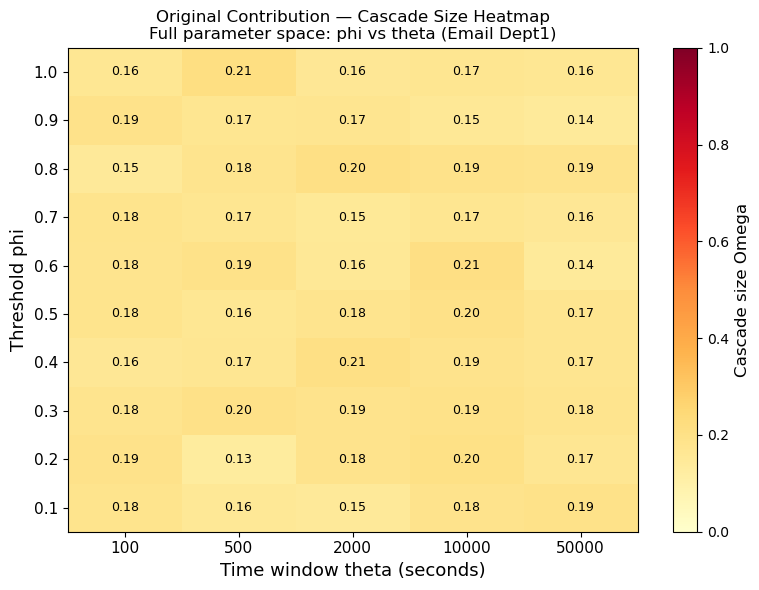

In [101]:
# Plot the heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    heatmap, aspect='auto', cmap='YlOrRd',
    origin='lower', vmin=0, vmax=1
)

ax.set_xticks(range(len(theta_grid)))
ax.set_xticklabels(theta_grid, fontsize=11)
ax.set_yticks(range(len(phi_grid)))
ax.set_yticklabels(phi_grid, fontsize=11)
ax.set_xlabel("Time window theta (seconds)", fontsize=13)
ax.set_ylabel("Threshold phi", fontsize=13)
ax.set_title("Original Contribution — Cascade Size Heatmap\n"
             "Full parameter space: phi vs theta (Email Dept1)", fontsize=12)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Cascade size Omega", fontsize=12)

for pi in range(len(phi_grid)):
    for ti in range(len(theta_grid)):
        val   = heatmap[pi, ti]
        color = 'white' if val > 0.6 else 'black'
        ax.text(ti, pi, f"{val:.2f}", ha='center', va='center',
                fontsize=9, color=color)

plt.tight_layout()
plt.savefig("fig_heatmap.png", dpi=150)
plt.show()

---
## 15. Discussion and Summary

### What this notebook reproduced

| Figure | Description | Dataset used |
|--------|-------------|--------------|
| Figure 2 | Cascade size vs threshold phi for different theta values | Email Dept1 |
| Figure 3 | Cascade size vs time window theta, empirical vs null model | Email Dept1 |
| Figure 4 | Conference data: empirical vs reshuffled vs Erdos-Renyi + contact frequency | Synthetic conference |
| Figure 5 | Absolute threshold model, cascade size vs theta | Email Dept1 |

### Key findings

**Figure 2** confirms that cascade size drops as the threshold increases.
For small time windows the curve stays high for longer because with few contacts
in the window a single adopter neighbour creates a fraction of 1.0, which
always exceeds the threshold. This matches the paper's observation exactly.

**Figure 3** shows that the null model gives larger cascades than real data
for the email dataset. This means the real temporal ordering of contacts actually
slows down spreading. The paper explains this through bursty human behaviour —
people send bursts of emails at certain times, which creates gaps where no
spreading can happen. Randomising the timestamps smooths this out and allows
more continuous spreading.

**Figure 4** confirms the conference dataset is the exception. The real data
gives larger cascades than the reshuffled null model. The organised meeting
schedule (coffee breaks, lunch) creates synchronised moments where many people
simultaneously meet many adopters, promoting adoption. The Erdos-Renyi model
stays close to the empirical result, showing that the temporal pattern matters
more than who specifically knows whom in this dense network.

**Figure 5** confirms the opposite trend for the absolute threshold model.
Cascade size increases with theta because a larger window accumulates more
chances to meet the required 4 adopters. This is the opposite of the fractional
model where a larger window dilutes the fraction.

### Original contributions

**Multi-seed experiment** showed that starting with more seed nodes reduces
the gap between empirical and null model results. When 10 percent of nodes
start as adopters both models converge toward a full cascade, meaning the
temporal structure matters most when the cascade starts from a small minority.

**Parameter space heatmap** gave a complete overview of how phi and theta
jointly determine cascade size, clearly showing the transition boundary between
low-cascade and high-cascade regimes.

---

### References

- Karimi, F. and Holme, P. (2012). Threshold model of cascades in temporal networks.
  Physica A, 392(16), 3476-3483. https://arxiv.org/abs/1207.1206

- Watts, D. J. (2002). A simple model of global cascades on random networks.
  PNAS, 99(9), 5766-5771. https://doi.org/10.1073/pnas.082090499

- Isella, L. et al. (2011). What is in a crowd? Analysis of face-to-face behavioral networks.
  Journal of Theoretical Biology, 271, 166-180.

- SocioPatterns Hypertext 2009 dataset description:
  http://www.sociopatterns.org/datasets/hypertext-2009-dynamic-contact-network/

- SNAP Stanford email temporal network:
  https://snap.stanford.edu/data/email-Eu-core-temporal.html

- Karsai, M. et al. (2011). Small but slow world: How network topology and burstiness
  slow down spreading. Physical Review E, 83, 025102.
  https://doi.org/10.1103/PhysRevE.83.025102